In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd

In [2]:
pd.read_csv(r"C:\Users\HP\Downloads\mall_kmeans.csv")

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
mall=pd.read_csv(r"C:\Users\HP\Downloads\mall_kmeans.csv")

In [4]:
mall=mall.drop(['CustomerID'],axis=1)

In [5]:
mall.rename(columns={'Annual Income (k$)':'Anuincome','Spending Score (1-100)':'spendingscore'},inplace=True)

In [6]:
mall.isnull().sum()[mall.isnull().sum()>0]

Series([], dtype: int64)

In [7]:
mall.Genre.value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

In [8]:
mall.Genre.replace({'Female':0,'Male':1},inplace=True)

In [9]:
mall.head()

,Genre,Age,Anuincome,spendingscore
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [10]:
from sklearn.cluster import KMeans
kmean_mall=KMeans(n_clusters=4)

In [11]:
kmean_mall.fit(mall)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [12]:
kmean_mall.labels_

array([0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 2, 1, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

In [13]:
len(kmean_mall.labels_)

200

In [14]:
pd.DataFrame(kmean_mall.labels_).value_counts()

0
1    96
2    39
3    37
0    28
Name: count, dtype: int64

In [15]:
cluster_center=pd.DataFrame(kmean_mall.cluster_centers_)

In [16]:
cluster_center

,0,1,2,3
0,0.500000,24.821429,28.714286,74.250000
1,0.385417,44.875000,48.937500,42.552083
2,0.461538,32.692308,86.538462,82.128205
3,0.513514,40.324324,87.432432,18.189189


In [17]:
cluster_center.columns=mall.columns

In [18]:
cluster_center

,Genre,Age,Anuincome,spendingscore
0,0.500000,24.821429,28.714286,74.250000
1,0.385417,44.875000,48.937500,42.552083
2,0.461538,32.692308,86.538462,82.128205
3,0.513514,40.324324,87.432432,18.189189


In [19]:
kmean_mall.score(mall)

-104422.8349853975

In [20]:
ssd=[]
for k in range(1,12):
    kmean_mall=KMeans(n_clusters=k)
    kmean_mall.fit(mall)
    score=kmean_mall.score(mall)
    ssd.append(score)
    print("Value of k is: ",k)

Value of k is:  1
Value of k is:  2
Value of k is:  3
Value of k is:  4
Value of k is:  5
Value of k is:  6
Value of k is:  7
Value of k is:  8
Value of k is:  9
Value of k is:  10
Value of k is:  11


In [21]:
import matplotlib.pyplot as plt

In [22]:
import numpy as np
ssd=np.abs(ssd)

Text(0, 0.5, 'SSD')

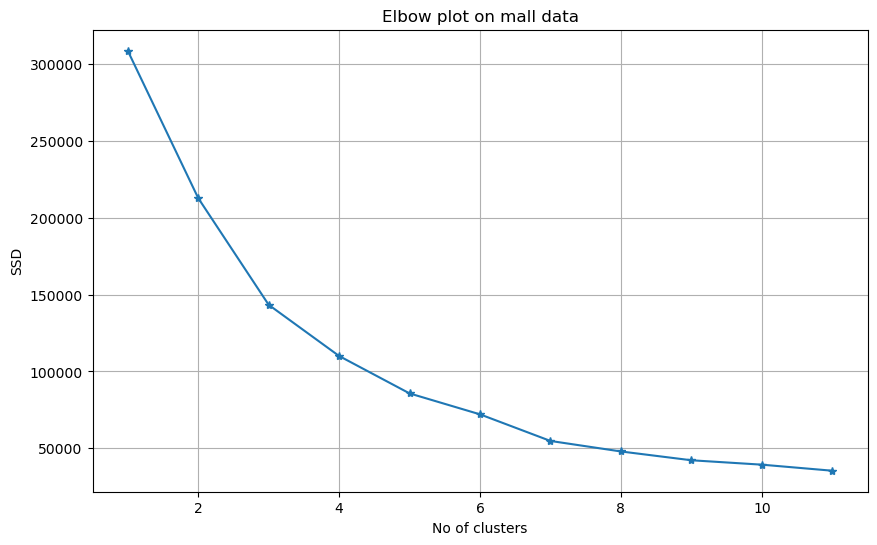

In [23]:
plt.figure(figsize=(10,6))
plt.plot(list(range(1,12)),ssd,marker='*')
plt.grid()
plt.title("Elbow plot on mall data")
plt.xlabel("No of clusters")
plt.ylabel("SSD")

In [24]:
from sklearn.cluster import KMeans
kmean_mall1=KMeans(n_clusters=6)
kmean_mall1.fit(mall)

,n_clusters,6
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [25]:
kmean_mall1.score(mall)

-75473.5976408608

In [26]:
pd.Series(kmean_mall1.labels_).value_counts()

0    53
1    50
3    34
5    28
4    24
2    11
Name: count, dtype: int64

In [27]:
mall['Cluster_number']=kmean_mall1.labels_

In [28]:
mall.head(20)

,Genre,Age,Anuincome,spendingscore,Cluster_number
0,1,19,15,39,4
1,1,21,15,81,4
2,0,20,16,6,1
3,0,23,16,77,4
4,0,31,17,40,1
5,0,22,17,76,4
6,0,35,18,6,1
7,0,23,18,94,4
8,1,64,19,3,1
9,0,30,19,72,4


In [29]:
colormap=np.array(['red','green','blue','black','yellow','purple'])

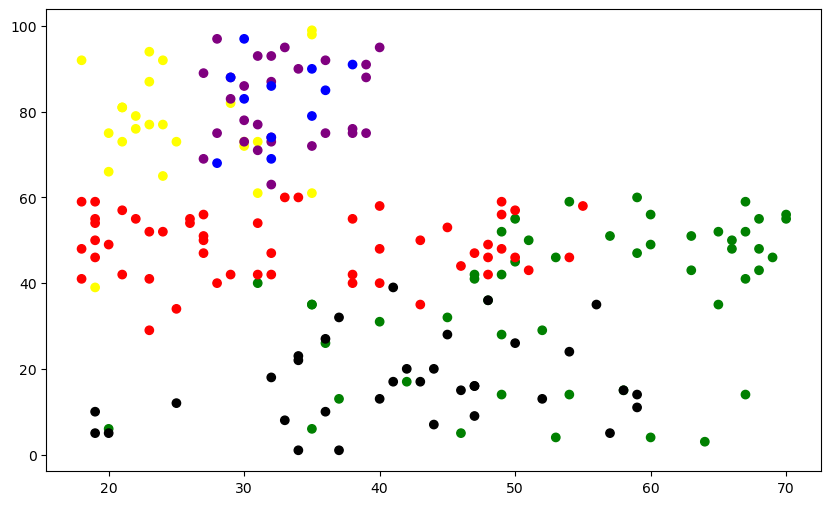

In [30]:
plt.figure(figsize=(10,6))
plt.scatter(mall.Age,mall.spendingscore,c=colormap[kmean_mall1.labels_])
plt.show()

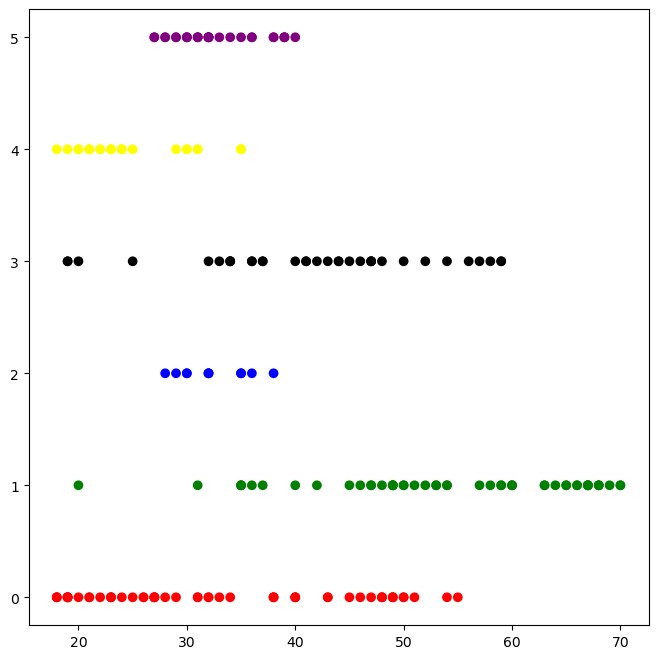

In [31]:
plt.figure(figsize=(8,8))
plt.scatter(mall.Age,mall.Cluster_number,c=colormap[kmean_mall1.labels_])
plt.show()

# Hierarchical Clustering

In [32]:
import pandas as pd

In [33]:
mall = pd.read_csv(r"C:\Users\HP\Downloads\mall_kmeans.csv")

In [34]:
mall.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [35]:
mall.drop('CustomerID', axis=1, inplace=True)

In [36]:
mall.rename(columns={'Annual Income (k$)': 'Income', 'Spending Score (1-100)': 'Score'}, inplace=True)

In [37]:
mall['Genre'].replace({'Female': 0, 'Male': 1}, inplace=True)

In [38]:
mall.head()

,Genre,Age,Income,Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [39]:
from sklearn.cluster import AgglomerativeClustering

In [40]:
agg_mall = AgglomerativeClustering(n_clusters=5, linkage='ward', metric='euclidean')
#mall['Cluster'] = agg_mall.fit_predict(mall)

In [41]:
agg_mall.fit(mall)

,n_clusters,5
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [42]:
agg_mall.labels_

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 0, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 0,
       4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2,
       0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2])

In [43]:
len(agg_mall.labels_)

200

In [44]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [45]:
mall['Cluster'] = agg_mall.fit_predict(mall)

In [46]:
mall['Cluster'].value_counts()

Cluster
0    83
2    39
1    35
4    23
3    20
Name: count, dtype: int64

In [47]:
# Features only (excluding cluster labels)
X = mall.drop('Cluster', axis=1)
labels = mall['Cluster']

In [48]:
# Evaluation metrics
sil_score = silhouette_score(X, labels)
sil_score

0.43997527212476695

In [49]:
mall.head()

,Genre,Age,Income,Score,Cluster
0,1,19,15,39,4
1,1,21,15,81,3
2,0,20,16,6,4
3,0,23,16,77,3
4,0,31,17,40,4


In [50]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np

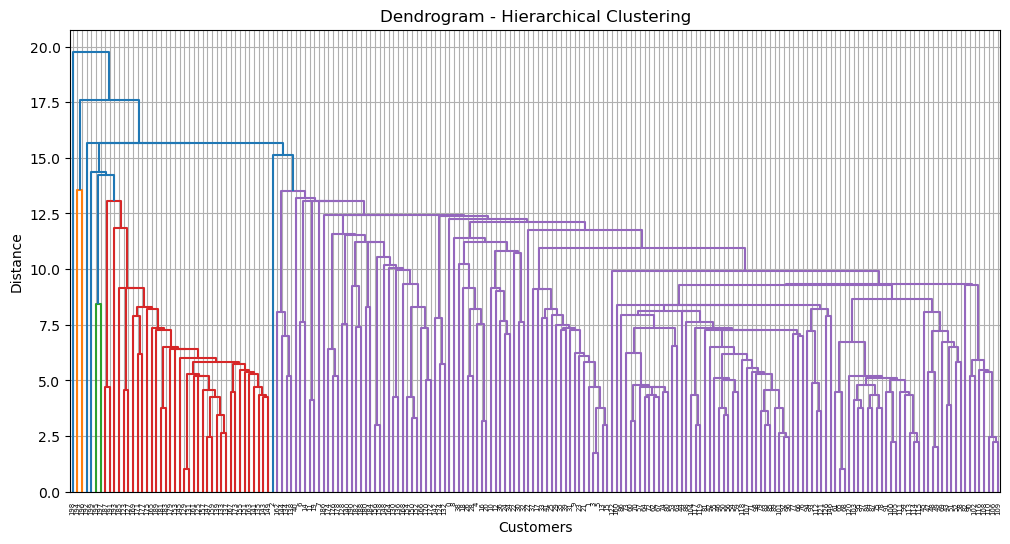

In [51]:
# Dendrogram to help choose number of clusters (optional but useful)
plt.figure(figsize=(12, 6))
link_result = linkage(mall.drop('Cluster', axis=1), method='single')
dendrogram(link_result)
plt.title("Dendrogram - Hierarchical Clustering")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.grid()
plt.show()

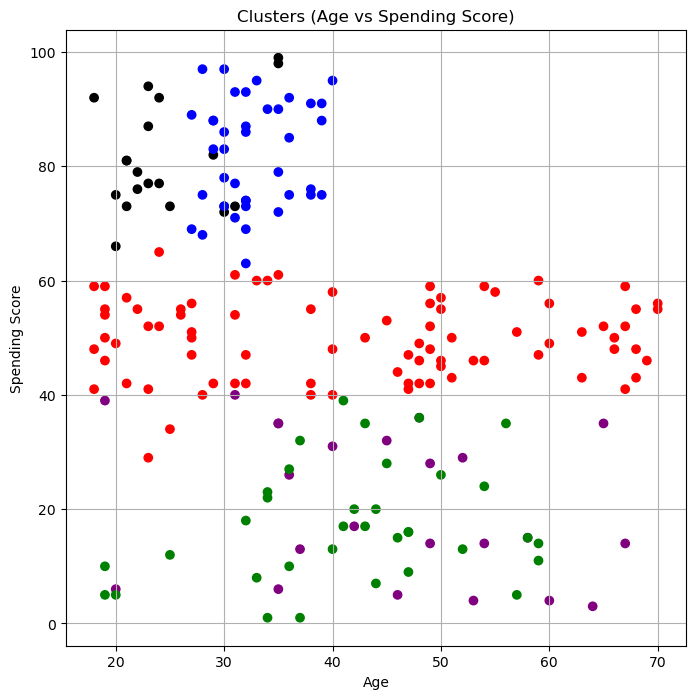

In [52]:
# Scatter plot: Age vs Spending Score colored by cluster
colors = np.array(['red', 'green', 'blue', 'black', 'purple'])

plt.figure(figsize=(8, 8))
plt.scatter(mall['Age'], mall['Score'], c=colors[mall['Cluster']])
plt.title("Clusters (Age vs Spending Score)")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.grid()
plt.show()